# Feature Selection

Missing-value handling, categorical encoding, correlation pruning, and
RF/permutation importance ranking. All fitting done on train only.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from churn.config import PROCESSED_DIR
from churn.selection.prepare import prepare_features
from churn.selection.select_features import get_feature_cols, drop_correlated_features, fit_rf_importance

FIGURES_DIR = Path.cwd().parent / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name: str):
    fig.savefig(FIGURES_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

train = pd.read_parquet(PROCESSED_DIR / "train.parquet")
test = pd.read_parquet(PROCESSED_DIR / "test.parquet")

train_prepped, test_prepped = prepare_features(train, test)

age median (from train): 42.0


one-hot columns learned from train: 14


## Correlation matrix (train only, post-encoding)

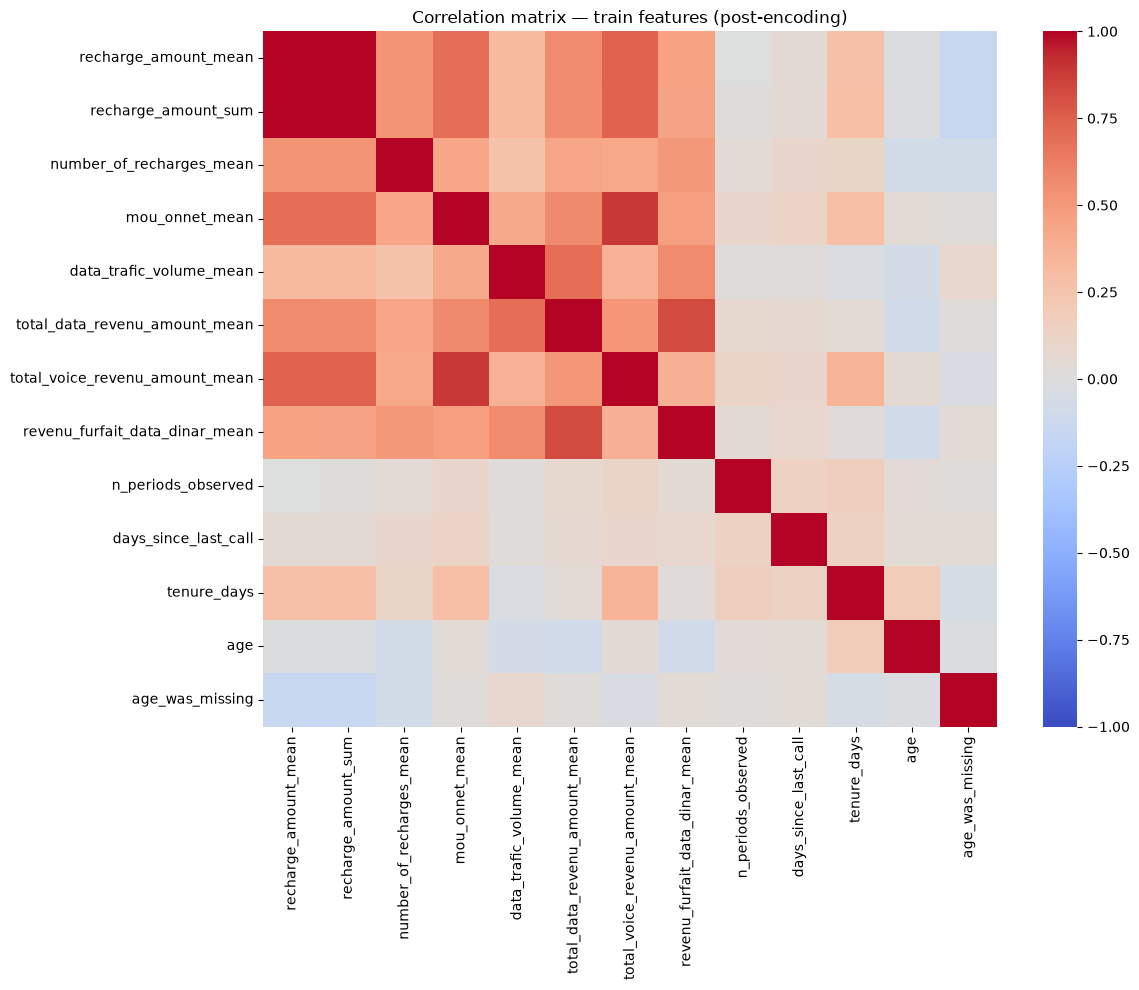

In [2]:
feature_cols = get_feature_cols(train_prepped)
numeric_cols = train_prepped[feature_cols].select_dtypes(include="number").columns
corr = train_prepped[numeric_cols].corr()

fig = plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation matrix — train features (post-encoding)")
plt.tight_layout()
save_fig(fig, "06_selection_correlation_heatmap")
plt.show()

In [3]:
kept_features = drop_correlated_features(train_prepped)

  dropping 'recharge_amount_sum' (correlated 1.00 with 'recharge_amount_mean')
  dropping 'total_voice_revenu_amount_mean' (correlated 0.88 with 'mou_onnet_mean')
Correlation pruning: dropped 2, kept 25 features


## Feature importance (RF + permutation, fit on train only)

                              feature  rf_importance  permutation_importance
                          tenure_days       0.181467            9.330955e-02
              data_trafic_volume_mean       0.134167            7.049625e-02
                                  age       0.082334            5.619398e-02
                       mou_onnet_mean       0.162019            4.442256e-02
     classe_anciennete_6 to 12 Months       0.005114            3.611645e-02
                 recharge_amount_mean       0.125809            3.457672e-02
                 days_since_last_call       0.079271            3.136865e-02
                             gender_M       0.005618            3.066599e-02
             number_of_recharges_mean       0.070667            2.969885e-02
        total_data_revenu_amount_mean       0.042002            2.705101e-02
                       gender_Missing       0.035527            2.102796e-02
       revenu_furfait_data_dinar_mean       0.020855            1.467939e-02

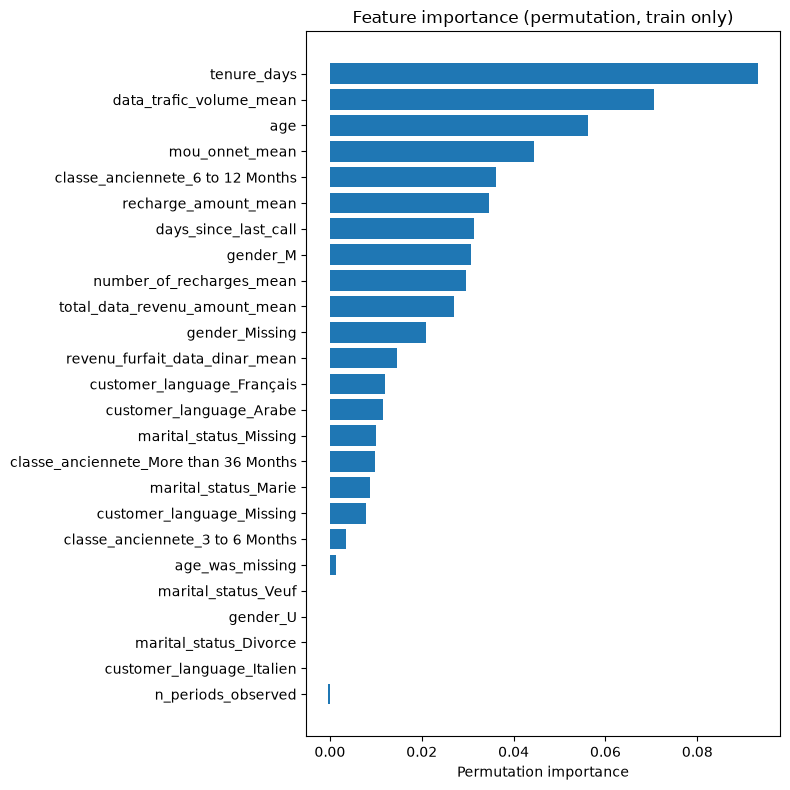

In [4]:
importance_df = fit_rf_importance(train_prepped, kept_features)
print(importance_df.to_string(index=False))

fig = plt.figure(figsize=(8, 8))
plt.barh(importance_df["feature"], importance_df["permutation_importance"])
plt.xlabel("Permutation importance")
plt.title("Feature importance (permutation, train only)")
plt.gca().invert_yaxis()
plt.tight_layout()
save_fig(fig, "07_selection_feature_importance")
plt.show()

**Observations — Feature selection**

- **Correlation pruning removed 2 redundant features:** `recharge_amount_sum` (perfectly correlated with `recharge_amount_mean`) and `total_voice_revenu_amount_mean` (highly correlated with `mou_onnet_mean`).

- **The most important features match earlier findings.** `days_since_last_call` and `tenure_days` rank highest, followed by the main usage variables (`data_trafic_volume_mean`, `mou_onnet_mean`, `recharge_amount_mean`). This is consistent with the EDA and survival analysis, where recency, tenure, and usage were the strongest churn indicators.

- **The `6 to 12 Months` tenure bucket remains important**, confirming that this group has the highest churn risk.

- **Keeping missing values as their own category was justified.** `gender_Missing` and `marital_status_Missing` show meaningful importance, while `age_was_missing` contributes very little.

- **Very small categories contribute almost nothing** (`gender_U`, `marital_status_Divorce`, `marital_status_Veuf`, `customer_language_Italien`), which is expected given their small sample sizes.

- **`n_periods_observed` Dropped, has slightly negative permutation importance**, redundant with tenure_days/days_since_last_call.

**Decision:** Final feature set 24 features. 